# Marketing ML Project

## Objectives
* Build a classifier that predicts wheter a person makes less than $50k or more than $50k given 40 demographic and employment related variables
* Create a segmentation model and demonstrate how the resulting groups differ from one another and how your client can use this model for marketing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

## Import dataset

In [2]:
# read column headers into a list
with open('TakeHomeProject/census-bureau.columns', 'r') as f:
    columns = [line.strip() for line in f]

# import main data
df = pd.read_csv('TakeHomeProject/census-bureau.data', header=None, names=columns)

# display first few rows
df.head()

,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


In [3]:
columns

['age',
 'class of worker',
 'detailed industry recode',
 'detailed occupation recode',
 'education',
 'wage per hour',
 'enroll in edu inst last wk',
 'marital stat',
 'major industry code',
 'major occupation code',
 'race',
 'hispanic origin',
 'sex',
 'member of a labor union',
 'reason for unemployment',
 'full or part time employment stat',
 'capital gains',
 'capital losses',
 'dividends from stocks',
 'tax filer stat',
 'region of previous residence',
 'state of previous residence',
 'detailed household and family stat',
 'detailed household summary in household',
 'weight',
 'migration code-change in msa',
 'migration code-change in reg',
 'migration code-move within reg',
 'live in this house 1 year ago',
 'migration prev res in sunbelt',
 'num persons worked for employer',
 'family members under 18',
 'country of birth father',
 'country of birth mother',
 'country of birth self',
 'citizenship',
 'own business or self employed',
 "fill inc questionnaire for veteran's admin"

### Notes
* "Not in universe" used; a distinct category rather than "missing" data
* "?" indicates missing data
* "weight indicates relative distribution of people in general population that each record represents due to stratified sampling"
* complex decision boundary -> motivation for gradient boosted decision tree model classification task
* weighted k-means clustering for segmentation task since weights are important in identifying statistically significant segments

## Data Visualizations

In [4]:
# preprocessing
df_clean = df.replace('?', 'NA') # handle missing values

# feature engineering
df_clean['total_financial_flow'] = df_clean['capital gains'] - df_clean['capital losses'] + df_clean['dividends from stocks'] 
df_clean['life_productivity'] = df_clean['age'] * df_clean['weeks worked in year']
df_clean['dual_income_flag'] = ((df_clean['marital stat'] == 'Married-civilian spouse present') & 
                                df_clean['tax filer stat'].str.contains('Joint')).astype(int)
df_clean['employment_stability'] = df_clean['class of worker'].astype(str) + "_" + df_clean['education'].astype(str)

# separate features and convert target to binary
y = df_clean['label'].apply(lambda x:1 if '50000+' in str(x) else 0).values 
weights = df_clean['weight'].values # extract weights
X = df_clean.drop(['label', 'weight', 'year'], axis=1) # prepare features

In [5]:
# encode categorical features as integers for xgboost
categorical = X.select_dtypes(include=['object']).columns
label_encoders = {}
for cat in categorical:
    le = LabelEncoder()
    X[cat] = le.fit_transform(X[cat].astype(str))
    label_encoders[cat] = le

In [6]:
# temp dataframe that matches encoded feature set + target
X_vis = X.copy()
X_vis['target'] = y

# calculate correlation matrix
corr_matrix = X_vis.corr()

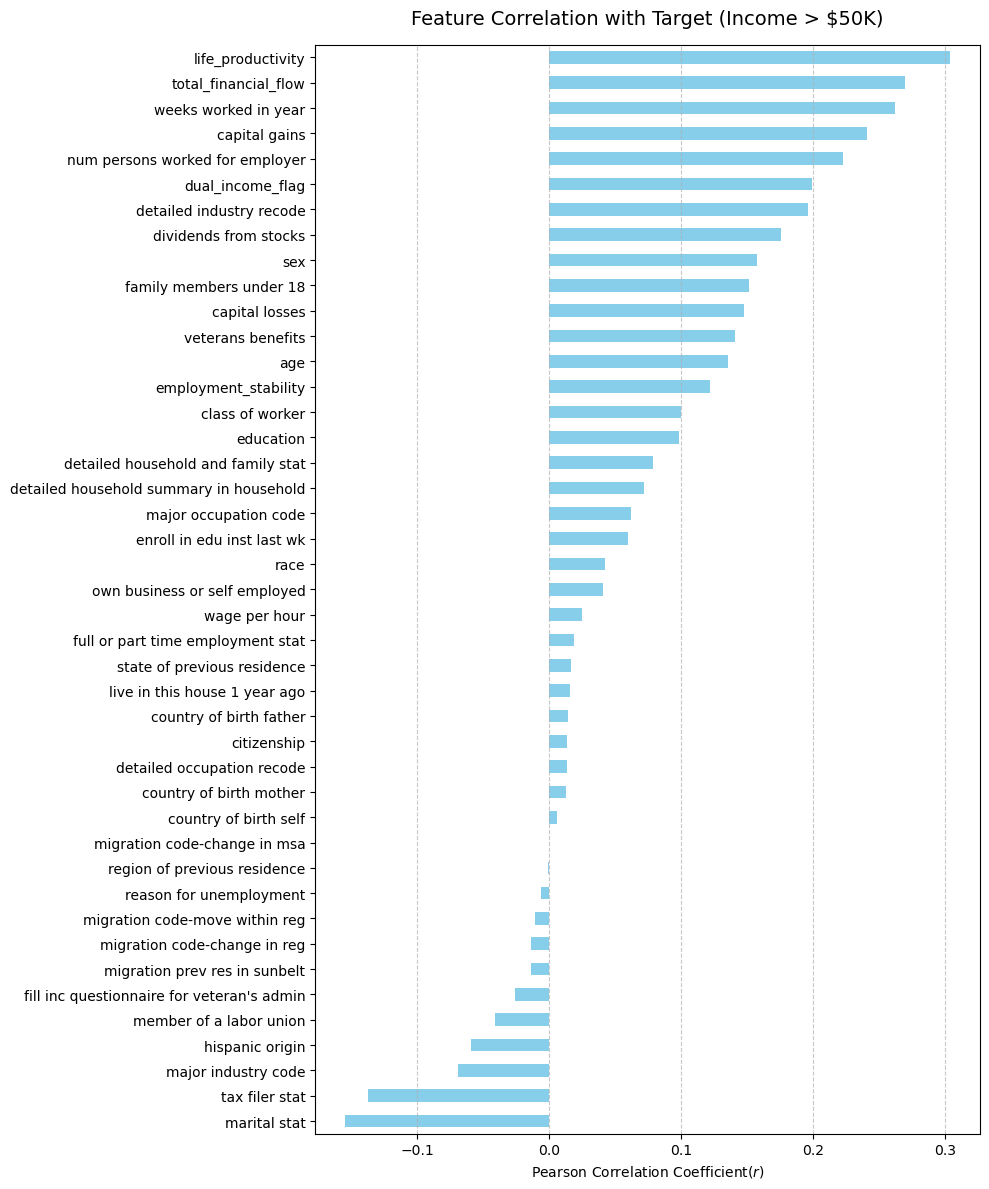

In [7]:
# feature correlation with target
target_corr = corr_matrix['target'].drop('target').sort_values(ascending=True)

plt.figure(figsize=(10, 12))
target_corr.plot(kind='barh', color='skyblue')
plt.title('Feature Correlation with Target (Income > $50K)', fontsize=14, pad=15)
plt.xlabel('Pearson Correlation Coefficient($r$)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig('feature_target_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

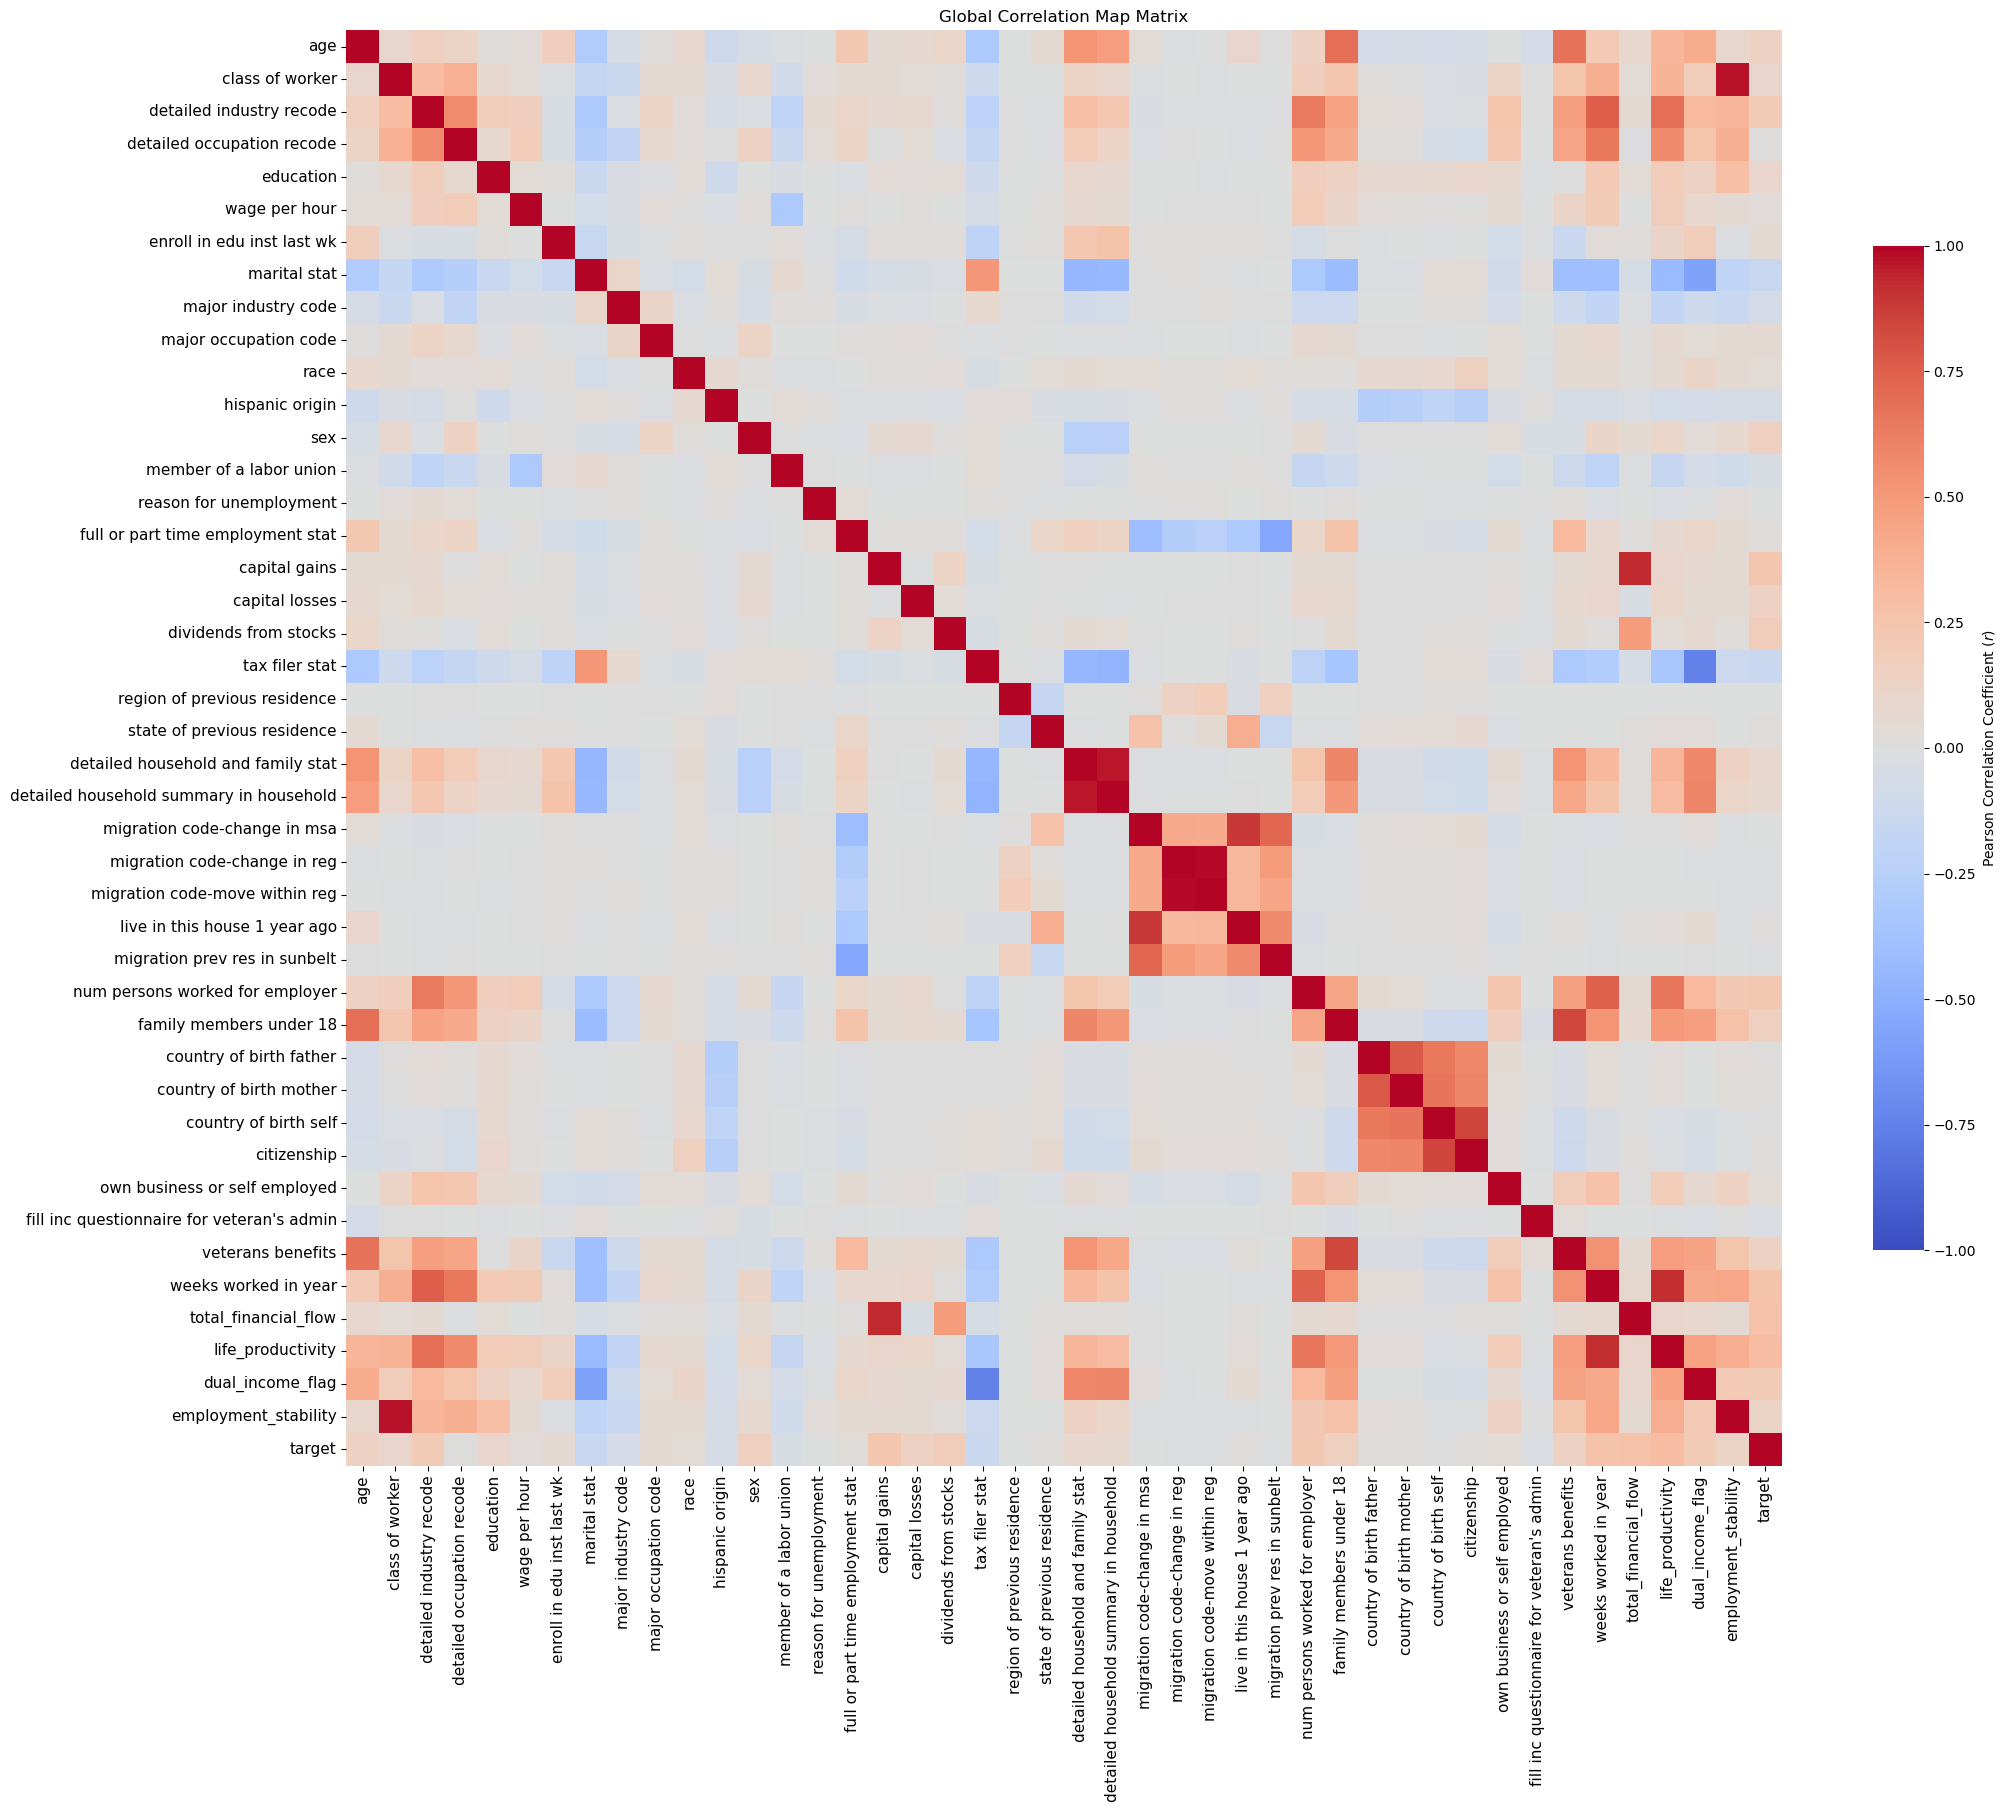

In [8]:
# correlation matrix
plt.figure(figsize=(22, 18))

sns.heatmap(
    corr_matrix, 
    annot=False,
    cmap='coolwarm',
    square=True,
    vmin=-1, vmax=1,
    cbar_kws={'shrink': 0.7, 'label': 'Pearson Correlation Coefficient ($r$)'}
)

plt.title('Global Correlation Map Matrix')

# label rotation and font sixes for readability
plt.xticks(rotation=90, fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
# plt.savefig(global_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## Classification Task

In [9]:
# split data
# 80% train & validation / 20% test
X_temp, X_test, y_temp, y_test, w_temp, w_test = train_test_split(
    X, y, weights, test_size=0.20, random_state=42, stratify=y
)

# take 20% from 80% split earlier for validation (total: 60% train/20% test/20% val)
X_train, X_val, y_train, y_val, w_train, w_val = train_test_split(
    X_temp, y_temp, w_temp, test_size=0.25, random_state=42, stratify=y_temp
)

In [10]:
# train model
# scale_pos_weight helps with class imbalance
ratio = np.sum(y == 0) / np.sum(y == 1)

classifier = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=ratio,
    subsample=0.8, # prevents rows from forcing overfit
    colsample_bytree=0.8, # forces trees to try engineered features
    random_state=42,
    use_label_encoder=False,
    early_stopping_rounds=50,
    eval_metric=['logloss', 'error']
)

classifier.fit(
    X_train, y_train,
    sample_weight=w_train, 
    eval_set=[(X_train, y_train), (X_val, y_val)],
    sample_weight_eval_set=[w_train, w_val],
    verbose=1
)

[0]	validation_0-logloss:0.67751	validation_0-error:0.21112	validation_1-logloss:0.67759	validation_1-error:0.21221
[1]	validation_0-logloss:0.65152	validation_0-error:0.19623	validation_1-logloss:0.65160	validation_1-error:0.19698
[2]	validation_0-logloss:0.62726	validation_0-error:0.18571	validation_1-logloss:0.62740	validation_1-error:0.18742
[3]	validation_0-logloss:0.60496	validation_0-error:0.18393	validation_1-logloss:0.60517	validation_1-error:0.18548
[4]	validation_0-logloss:0.58491	validation_0-error:0.18318	validation_1-logloss:0.58519	validation_1-error:0.18572
[5]	validation_0-logloss:0.56739	validation_0-error:0.18232	validation_1-logloss:0.56763	validation_1-error:0.18441
[6]	validation_0-logloss:0.55031	validation_0-error:0.17866	validation_1-logloss:0.55069	validation_1-error:0.18155
[7]	validation_0-logloss:0.53509	validation_0-error:0.17822	validation_1-logloss:0.53554	validation_1-error:0.18058
[8]	validation_0-logloss:0.52130	validation_0-error:0.18020	validation_1

c:\Users\dorot\anaconda3\Lib\site-packages\xgboost\callback.py:385: UserWarning: [16:05:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[10]	validation_0-logloss:0.49552	validation_0-error:0.17701	validation_1-logloss:0.49607	validation_1-error:0.17877
[11]	validation_0-logloss:0.48404	validation_0-error:0.17711	validation_1-logloss:0.48463	validation_1-error:0.17867
[12]	validation_0-logloss:0.47325	validation_0-error:0.17619	validation_1-logloss:0.47379	validation_1-error:0.17729
[13]	validation_0-logloss:0.46347	validation_0-error:0.17096	validation_1-logloss:0.46396	validation_1-error:0.17257
[14]	validation_0-logloss:0.45423	validation_0-error:0.17296	validation_1-logloss:0.45470	validation_1-error:0.17445
[15]	validation_0-logloss:0.44563	validation_0-error:0.17515	validation_1-logloss:0.44618	validation_1-error:0.17624
[16]	validation_0-logloss:0.43787	validation_0-error:0.17541	validation_1-logloss:0.43851	validation_1-error:0.17663
[17]	validation_0-logloss:0.43030	validation_0-error:0.17651	validation_1-logloss:0.43094	validation_1-error:0.17818
[18]	validation_0-logloss:0.42312	validation_0-error:0.17326	val

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=50,
              enable_categorical=False, eval_metric=['logloss', 'error'],
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

Final Evaluation
              precision    recall  f1-score   support

           0       0.99      0.92      0.95 64953101.679999925
           1       0.40      0.81      0.53 4483480.5600000145

    accuracy                           0.91 69436582.23999994
   macro avg       0.69      0.86      0.74 69436582.23999994
weighted avg       0.95      0.91      0.92 69436582.23999994



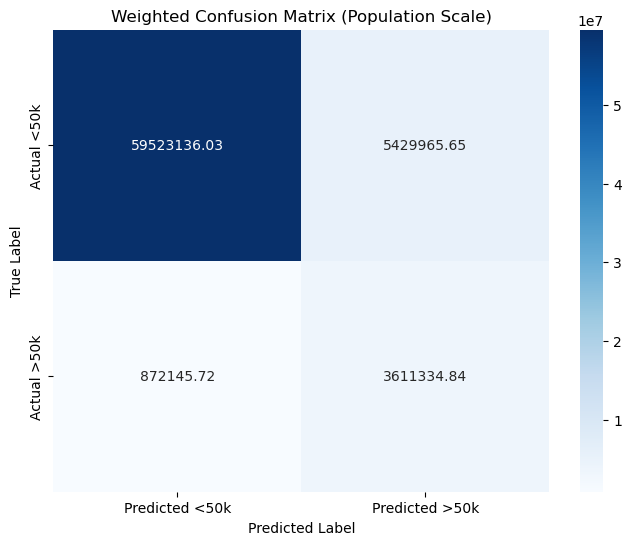

Top 10 Predictive Variables for Income
life_productivity                     0.127706
sex                                   0.081462
weeks worked in year                  0.054678
num persons worked for employer       0.047951
total_financial_flow                  0.046514
family members under 18               0.044166
detailed occupation recode            0.041760
detailed household and family stat    0.028489
dual_income_flag                      0.026469
education                             0.026090
dtype: float32


In [11]:
# validation & evaluation
print("Final Evaluation")
y_pred = classifier.predict(X_test)
print(classification_report(y_test, y_pred, sample_weight=w_test)) # use sample_weight in report to reflect population distribution

# confusion matrix visualization
cm = confusion_matrix(y_test, y_pred, sample_weight=w_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Predicted <50k', 'Predicted >50k'],
            yticklabels=['Actual <50k', 'Actual >50k'])
plt.title('Weighted Confusion Matrix (Population Scale)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


important_features = pd.Series(classifier.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 10 Predictive Variables for Income")
print(important_features.head(10))

### Notes
#### Implementation:
* class 0 high precision (0.99) high recall (0.91)
* class 1 low precision (0.38) acceptable recall (0.83)
* overall accuracy 0.90

ways to adjust:
1) adjust classification threshold
2) lower/remove scale_pos_weight, may decrease recall
3) feature engineering

---

#### Fix 1: adjust classification threshold(0.75)
Result: precision of class 0 decreased (0.98) and recall increased (0.96), increases precision (0.54) of class 1 but lowers recall (0.69), overall accuracy 0.94

#### Fix 2: slower learning_rate 0.05 -> 0.03, max_depth 6 -> 7, scale_pos_weight=1, added max_delta_step=1
Result: Overly conservative model, never predicts 1

#### Fix 2b: sqrt ratio, added subsample=0.8, added colsample_bytree=0.8*
Result: class 0 precision 0.96, recall 0.99; class 1 precision 0.69, recall 0.38; overall accuracy 0.95

#### Fix 3: feature engineering (total_financial_flow, life_productivity, dual_income_flag, employment_stability)
Result: class 0 precision same, recall +0.1; class 1 precision +0.2, recall -0.2; overall accuracy 0.91
* improved fundamental predictablility
* model uses engineered metrics to spot high earners
* options:
    1) use the model as is, captures majority of the available wealth in the population; option comprehensive customer discovery and retention -> capture
    2) more feature engineering 
    3) reintroduce custom probability threshold for higher precision; option for direct marketing and targeted campaigns -> conversion

## Resources
https://xgboost.readthedocs.io/en/release_3.2.0/tutorials/model.html
https://medium.com/data-science/stop-saying-precision-and-recall-to-business-leaders-f17082ab5052